# 01 - Exploratory Data Analysis
## Amazon Product Intelligence System

**Objective:**  
This notebook explores the Amazon Fine Food Reviews dataset to uncover patterns, biases, and business-relevant signals that will directly inform our modeling decisions in later notebooks.

**Dataset:** [Amazon Fine Food Reviews](https://www.kaggle.com/datasets/snap/amazon-fine-food-reviews)  
**Records:** ~568,000 reviews  
**Key Columns:** `Id`, `ProductId`, `UserId`, `HelpfulnessNumerator`, `HelpfulnessDenominator`, `Score`, `Time`, `Summary`, `Text`

In [1]:
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import re
from collections import Counter
import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from wordcloud import WordCloud
from datetime import datetime
import warnings
warnings.filterwarnings('ignore')

nltk.download('stopwords', quiet=True)
nltk.download('punkt', quiet=True)
nltk.download('punkt_tab', quiet=True)

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['font.size'] = 12

print('All libraries imported successfully.')

All libraries imported successfully.


In [2]:
# Load data
df = pd.read_csv('../data/raw/Reviews.csv')

print(f'Dataset shape: {df.shape}')
print(f'Total reviews: {len(df):,}')
print(f'Total columns: {df.shape[1]}')

Dataset shape: (568454, 10)
Total reviews: 568,454
Total columns: 10


In [3]:
df.head()

,Id,ProductId,UserId,ProfileName,HelpfulnessNumerator,HelpfulnessDenominator,Score,Time,Summary,Text
0,1,B001E4KFG0,A3SGXH7AUHU8GW,delmartian,1,1,5,1303862400,Good Quality Dog Food,I have bought several of the Vitality canned d...
1,2,B00813GRG4,A1D87F6ZCVE5NK,dll pa,0,0,1,1346976000,Not as Advertised,Product arrived labeled as Jumbo Salted Peanut...
2,3,B000LQOCH0,ABXLMWJIXXAIN,"Natalia Corres ""Natalia Corres""",1,1,4,1219017600,"""Delight"" says it all",This is a confection that has been around a fe...
3,4,B000UA0QIQ,A395BORC6FGVXV,Karl,3,3,2,1307923200,Cough Medicine,If you are looking for the secret ingredient i...
4,5,B006K2ZZ7K,A1UQRSCLF8GW1T,"Michael D. Bigham ""M. Wassir""",0,0,5,1350777600,Great taffy,Great taffy at a great price. There was a wid...


In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 568454 entries, 0 to 568453
Data columns (total 10 columns):
 #   Column                  Non-Null Count   Dtype
---  ------                  --------------   -----
 0   Id                      568454 non-null  int64
 1   ProductId               568454 non-null  str  
 2   UserId                  568454 non-null  str  
 3   ProfileName             568428 non-null  str  
 4   HelpfulnessNumerator    568454 non-null  int64
 5   HelpfulnessDenominator  568454 non-null  int64
 6   Score                   568454 non-null  int64
 7   Time                    568454 non-null  int64
 8   Summary                 568427 non-null  str  
 9   Text                    568454 non-null  str  
dtypes: int64(5), str(5)
memory usage: 313.1 MB


In [5]:
df.describe()

,Id,HelpfulnessNumerator,HelpfulnessDenominator,Score,Time
count,568454.000000,568454.000000,568454.00000,568454.000000,5.684540e+05
mean,284227.500000,1.743817,2.22881,4.183199,1.296257e+09
std,164098.679298,7.636513,8.28974,1.310436,4.804331e+07
min,1.000000,0.000000,0.00000,1.000000,9.393408e+08
25%,142114.250000,0.000000,0.00000,4.000000,1.271290e+09
50%,284227.500000,0.000000,1.00000,5.000000,1.311120e+09
75%,426340.750000,2.000000,2.00000,5.000000,1.332720e+09
max,568454.000000,866.000000,923.00000,5.000000,1.351210e+09


In [6]:
# Check for missing values
missing = df.isnull().sum()
missing_pct = (missing / len(df)) * 100

missing_df = pd.DataFrame({
    'Missing Count': missing,
    'Missing %': missing_pct.round(2)
})

print('Missing Values Summary:')
print(missing_df[missing_df['Missing Count'] > 0])

Missing Values Summary:
             Missing Count  Missing %
ProfileName             26        0.0
Summary                 27        0.0


In [7]:
duplicates = df.duplicated(subset=['UserId', 'ProductId', 'Text']).sum()
print(f'Duplicate reviews: {duplicates:,}')
print(f'Duplicate percentage: {(duplicates / len(df) * 100):.2f}%')

Duplicate reviews: 1,309
Duplicate percentage: 0.23%


In [8]:
print('Unique score values:', sorted(df['Score'].unique()))
print('\nScore value counts:')
print(df['Score'].value_counts().sort_index())

Unique score values: [np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5)]

Score value counts:
Score
1     52268
2     29769
3     42640
4     80655
5    363122
Name: count, dtype: int64


In [9]:
invalid_helpfulness = df[df['HelpfulnessNumerator'] > df['HelpfulnessDenominator']]
print(f'Reviews with invalid helpfulness data: {len(invalid_helpfulness):,}')
print('\nSample of invalid helpfulness rows:')
invalid_helpfulness[['HelpfulnessNumerator', 'HelpfulnessDenominator', 'Score']].head()

Reviews with invalid helpfulness data: 2

Sample of invalid helpfulness rows:


,HelpfulnessNumerator,HelpfulnessDenominator,Score
44736,3,2,4
64421,3,1,5


In [10]:
df['word_count'] = df['Text'].fillna('').apply(lambda x: len(str(x).split()))
short_reviews = df[df['word_count'] < 5]
print(f'Reviews with fewer than 5 words: {len(short_reviews):,}')
print('\nSample short reviews:')
short_reviews[['Score', 'Text', 'word_count']].head(10)

Reviews with fewer than 5 words: 3

Sample short reviews:


,Score,Text,word_count
168550,5,they are excellent,3
234392,5,OUR FAVORITE! EXCELLENT ITEM!!,4
453668,1,Not worth it,3


**Data Quality Summary:**  
We identified missing values in `ProfileName` and `Summary`, duplicate reviews, invalid helpfulness entries, and very short reviews. All of these will be handled systematically in `02_preprocessing.ipynb`. Noting them here demonstrates awareness of real-world data messiness before any modeling begins.

In [11]:
# Rating Distribution Analysis
rating_counts = df['Score'].value_counts().sort_index()
rating_pct = (rating_counts / len(df) * 100).round(2)

print('Rating Distribution:')
for score, count, pct in zip(rating_counts.index, rating_counts.values, rating_pct.values):
    print(f'  {score} star: {count:,} reviews ({pct}%)')

Rating Distribution:
  1 star: 52,268 reviews (9.19%)
  2 star: 29,769 reviews (5.24%)
  3 star: 42,640 reviews (7.5%)
  4 star: 80,655 reviews (14.19%)
  5 star: 363,122 reviews (63.88%)


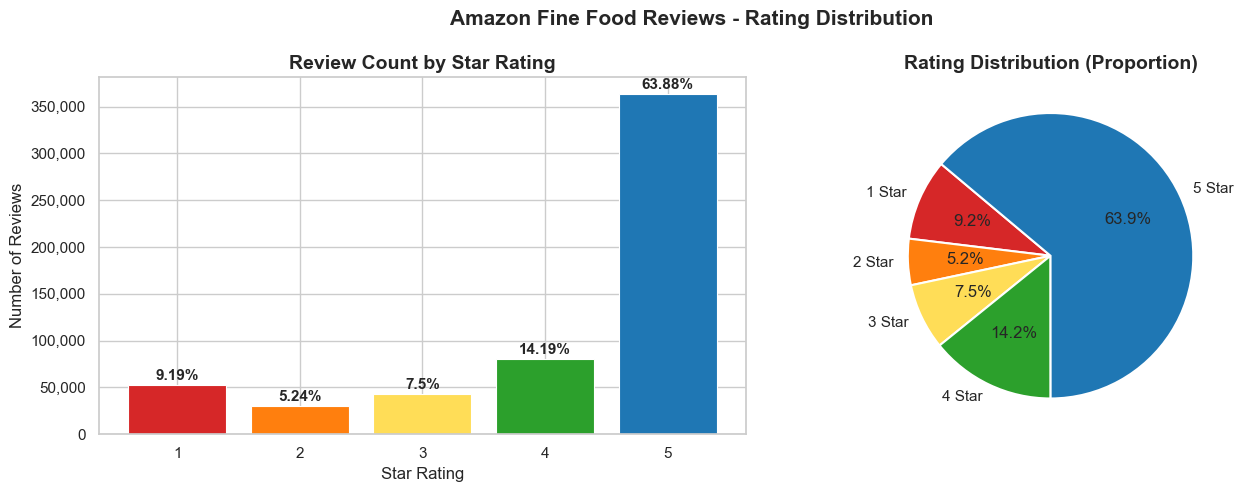

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

colors = ['#d62728', '#ff7f0e', '#ffdd57', '#2ca02c', '#1f77b4']

# Bar chart
bars = axes[0].bar(rating_counts.index, rating_counts.values,
                   color=colors, edgecolor='white', linewidth=0.8)
axes[0].set_title('Review Count by Star Rating', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Star Rating')
axes[0].set_ylabel('Number of Reviews')
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
for bar, pct in zip(bars, rating_pct):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 2000,
                 f'{pct}%', ha='center', va='bottom', fontsize=11, fontweight='bold')

# Pie chart
axes[1].pie(rating_counts.values,
            labels=[f'{i} Star' for i in rating_counts.index],
            autopct='%1.1f%%', colors=colors, startangle=140,
            wedgeprops={'edgecolor': 'white', 'linewidth': 1.5})
axes[1].set_title('Rating Distribution (Proportion)', fontsize=14, fontweight='bold')

plt.suptitle('Amazon Fine Food Reviews - Rating Distribution', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig('../outputs/figures/rating_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

In [13]:
df['sentiment'] = df['Score'].apply(lambda x: 'Positive' if x >= 4 else 'Negative')

sentiment_counts = df['sentiment'].value_counts()
print('Binary Sentiment Split:')
print(sentiment_counts)
print(f'\nClass imbalance ratio: {sentiment_counts["Positive"] / sentiment_counts["Negative"]:.2f}x more positive reviews')

Binary Sentiment Split:
sentiment
Positive    443777
Negative    124677
Name: count, dtype: int64

Class imbalance ratio: 3.56x more positive reviews


**Business Insight:**  
Over 63% of reviews are 5-star. This is known as **positivity bias** and is extremely common on e-commerce platforms. Users who had a neutral experience rarely bother leaving a review at all.

This has a direct implication for modeling: a naive classifier that predicts "Positive" for everything would already achieve high accuracy, making accuracy a completely misleading metric. In our classification notebook, we will use **F1-score** and pay close attention to minority class (negative) performance instead.

In [14]:
# Review Length Analysis
df['char_count'] = df['Text'].fillna('').apply(len)

print('Word Count Statistics:')
print(df['word_count'].describe().round(2))
print('\nCharacter Count Statistics:')
print(df['char_count'].describe().round(2))

Word Count Statistics:
count    568454.00
mean         80.26
std          79.46
min           3.00
25%          33.00
50%          56.00
75%          98.00
max        3432.00
Name: word_count, dtype: float64

Character Count Statistics:
count    568454.00
mean        436.22
std         445.34
min          12.00
25%         179.00
50%         302.00
75%         527.00
max       21409.00
Name: char_count, dtype: float64


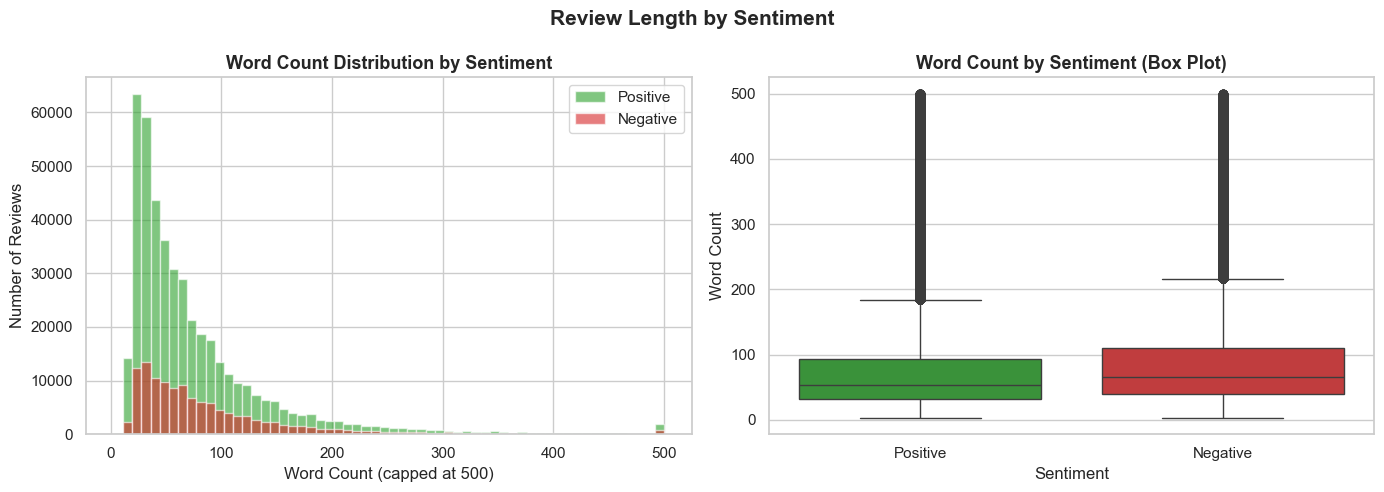

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for sentiment, color in zip(['Positive', 'Negative'], ['#2ca02c', '#d62728']):
    subset = df[df['sentiment'] == sentiment]['word_count'].clip(upper=500)
    axes[0].hist(subset, bins=60, alpha=0.6, label=sentiment, color=color, edgecolor='white')

axes[0].set_title('Word Count Distribution by Sentiment', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Word Count (capped at 500)')
axes[0].set_ylabel('Number of Reviews')
axes[0].legend()

plot_data = df[df['word_count'] <= 500]
sns.boxplot(data=plot_data, x='sentiment', y='word_count',
            palette={'Positive': '#2ca02c', 'Negative': '#d62728'}, ax=axes[1])
axes[1].set_title('Word Count by Sentiment (Box Plot)', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Sentiment')
axes[1].set_ylabel('Word Count')

plt.suptitle('Review Length by Sentiment', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig('../outputs/figures/review_length_by_sentiment.png', dpi=150, bbox_inches='tight')
plt.show()

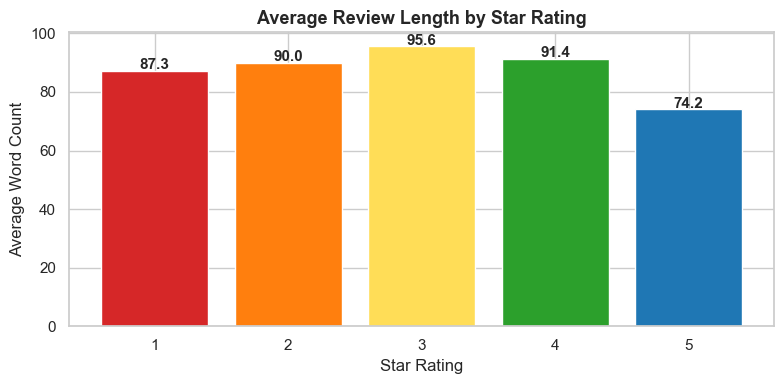

In [16]:
mean_wc_by_score = df.groupby('Score')['word_count'].mean().round(1)

fig, ax = plt.subplots(figsize=(8, 4))
colors = ['#d62728', '#ff7f0e', '#ffdd57', '#2ca02c', '#1f77b4']
bars = ax.bar(mean_wc_by_score.index, mean_wc_by_score.values,
              color=colors, edgecolor='white')
ax.set_title('Average Review Length by Star Rating', fontsize=13, fontweight='bold')
ax.set_xlabel('Star Rating')
ax.set_ylabel('Average Word Count')
for bar, val in zip(bars, mean_wc_by_score.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
            f'{val}', ha='center', fontsize=11, fontweight='bold')
plt.tight_layout()
plt.savefig('../outputs/figures/avg_word_count_by_rating.png', dpi=150, bbox_inches='tight')
plt.show()

**Business Insight:**  
Lower-rated reviews are consistently longer. Dissatisfied customers invest more effort explaining what went wrong. This confirms two things:

1. Negative reviews contain **richer textual signal** for topic modeling and complaint detection.
2. `word_count` is a useful feature for our classifier since review length correlates with sentiment.

In [17]:
# Helpfulness Analysis
df_help = df[df['HelpfulnessDenominator'] > 0].copy()
df_help['helpfulness_ratio'] = df_help['HelpfulnessNumerator'] / df_help['HelpfulnessDenominator']

print(f'Reviews with at least one helpfulness vote: {len(df_help):,} ({len(df_help)/len(df)*100:.1f}%)')
print(f'Mean helpfulness ratio: {df_help["helpfulness_ratio"].mean():.3f}')
print(f'Reviews with 100% helpful votes: {(df_help["helpfulness_ratio"] == 1.0).sum():,}')

Reviews with at least one helpfulness vote: 298,402 (52.5%)
Mean helpfulness ratio: 0.777
Reviews with 100% helpful votes: 183,309


Average Helpfulness Ratio by Star Rating:
Score
1    0.539
2    0.566
3    0.626
4    0.791
5    0.872
Name: helpfulness_ratio, dtype: float64


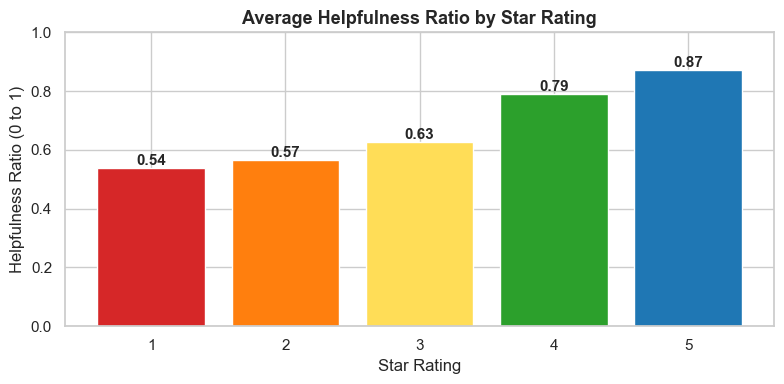

In [18]:
help_by_score = df_help.groupby('Score')['helpfulness_ratio'].mean().round(3)
print('Average Helpfulness Ratio by Star Rating:')
print(help_by_score)

fig, ax = plt.subplots(figsize=(8, 4))
colors = ['#d62728', '#ff7f0e', '#ffdd57', '#2ca02c', '#1f77b4']
bars = ax.bar(help_by_score.index, help_by_score.values, color=colors, edgecolor='white')
ax.set_title('Average Helpfulness Ratio by Star Rating', fontsize=13, fontweight='bold')
ax.set_xlabel('Star Rating')
ax.set_ylabel('Helpfulness Ratio (0 to 1)')
ax.set_ylim(0, 1)
for bar, val in zip(bars, help_by_score.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
            f'{val:.2f}', ha='center', fontsize=11, fontweight='bold')
plt.tight_layout()
plt.savefig('../outputs/figures/helpfulness_by_rating.png', dpi=150, bbox_inches='tight')
plt.show()

Correlation between Word Count and Helpfulness Ratio:
                   word_count  helpfulness_ratio
word_count            1.00000            0.04087
helpfulness_ratio     0.04087            1.00000


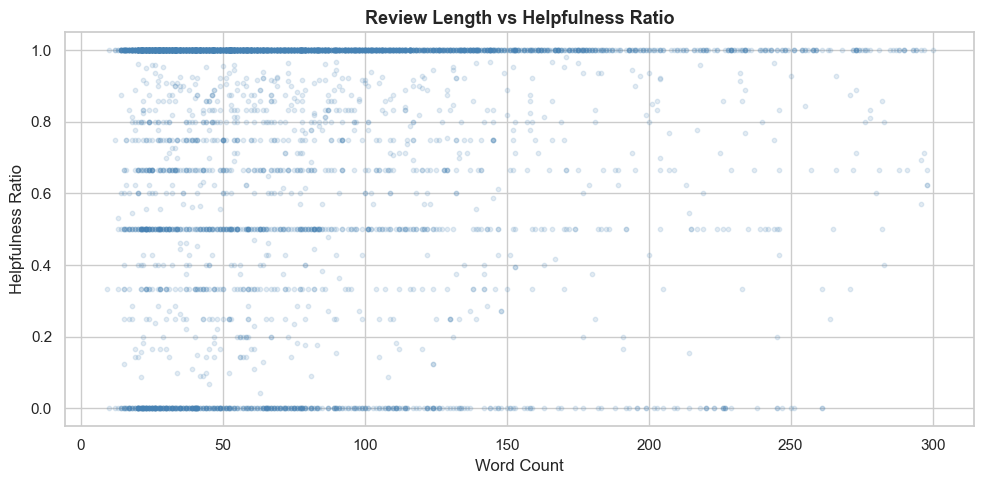

In [19]:
corr = df_help[['word_count', 'helpfulness_ratio']].corr()
print('Correlation between Word Count and Helpfulness Ratio:')
print(corr)

sample = df_help[df_help['word_count'] <= 300].sample(5000, random_state=42)
fig, ax = plt.subplots(figsize=(10, 5))
ax.scatter(sample['word_count'], sample['helpfulness_ratio'],
           alpha=0.15, color='steelblue', s=10)
ax.set_title('Review Length vs Helpfulness Ratio', fontsize=13, fontweight='bold')
ax.set_xlabel('Word Count')
ax.set_ylabel('Helpfulness Ratio')
plt.tight_layout()
plt.savefig('../outputs/figures/length_vs_helpfulness.png', dpi=150, bbox_inches='tight')
plt.show()

**Business Insight:**  
Helpfulness ratio varies meaningfully by rating. Negative and mid-range reviews tend to be rated most helpful, likely because they warn buyers or provide balanced context.

This metric can serve as a **proxy for review quality** in two ways:
1. Use it to weight training samples, giving more importance to reviews other users found genuinely useful.
2. Use it in a production system to surface the most helpful reviews at the top, rather than the most recent ones.

In [20]:
# Temporal Analysis
df['review_date'] = pd.to_datetime(df['Time'], unit='s')
df['year'] = df['review_date'].dt.year
df['month'] = df['review_date'].dt.month
df['year_month'] = df['review_date'].dt.to_period('M')

print('Review date range:')
print(f'Earliest: {df["review_date"].min().date()}')
print(f'Latest:   {df["review_date"].max().date()}')
print(f'Span: {(df["review_date"].max() - df["review_date"].min()).days // 365} years')

Review date range:
Earliest: 1999-10-08
Latest:   2012-10-26
Span: 13 years


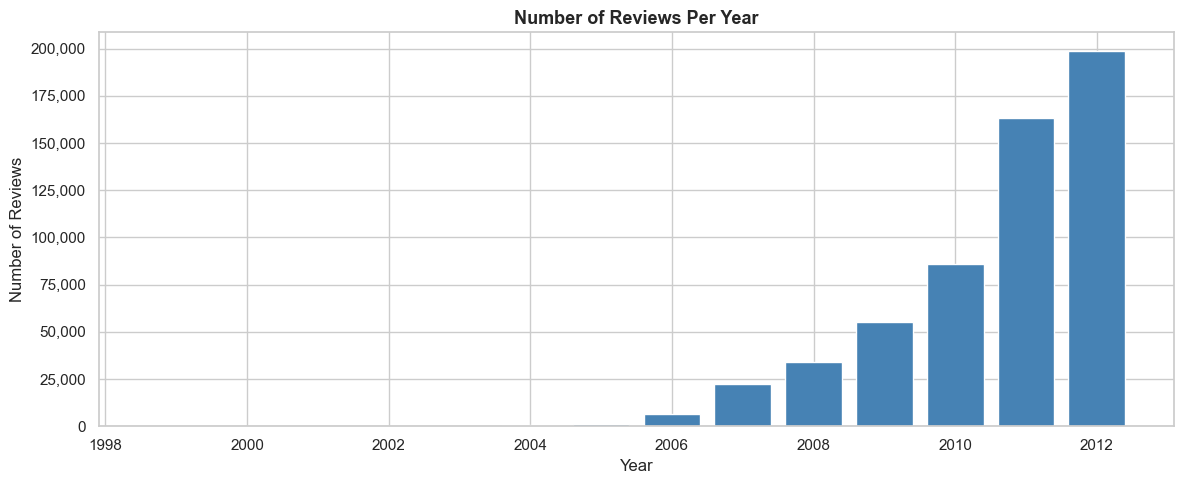

In [21]:
reviews_by_year = df.groupby('year').size()

fig, ax = plt.subplots(figsize=(12, 5))
ax.bar(reviews_by_year.index, reviews_by_year.values,
       color='steelblue', edgecolor='white')
ax.set_title('Number of Reviews Per Year', fontsize=13, fontweight='bold')
ax.set_xlabel('Year')
ax.set_ylabel('Number of Reviews')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
plt.tight_layout()
plt.savefig('../outputs/figures/reviews_per_year.png', dpi=150, bbox_inches='tight')
plt.show()

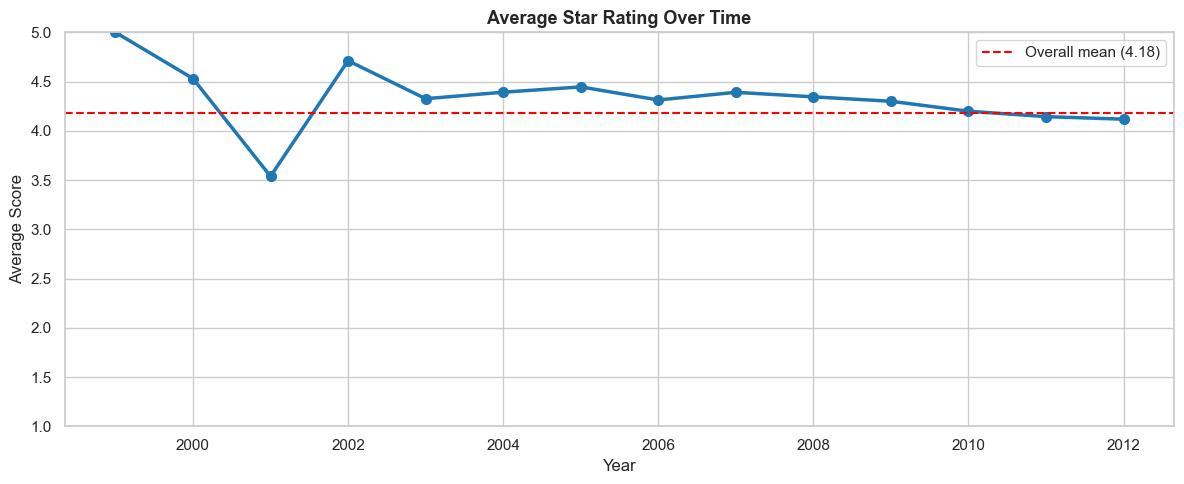

Average rating by year:
year
1999    5.000
2000    4.531
2001    3.538
2002    4.712
2003    4.326
2004    4.392
2005    4.446
2006    4.313
2007    4.391
2008    4.345
2009    4.300
2010    4.199
2011    4.144
2012    4.118
Name: Score, dtype: float64


In [22]:
avg_rating_by_year = df.groupby('year')['Score'].mean().round(3)

fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(avg_rating_by_year.index, avg_rating_by_year.values,
        marker='o', color='#1f77b4', linewidth=2.5, markersize=7)
ax.set_title('Average Star Rating Over Time', fontsize=13, fontweight='bold')
ax.set_xlabel('Year')
ax.set_ylabel('Average Score')
ax.set_ylim(1, 5)
ax.axhline(y=df['Score'].mean(), color='red', linestyle='--', linewidth=1.5,
           label=f'Overall mean ({df["Score"].mean():.2f})')
ax.legend()
plt.tight_layout()
plt.savefig('../outputs/figures/avg_rating_over_time.png', dpi=150, bbox_inches='tight')
plt.show()

print('Average rating by year:')
print(avg_rating_by_year)

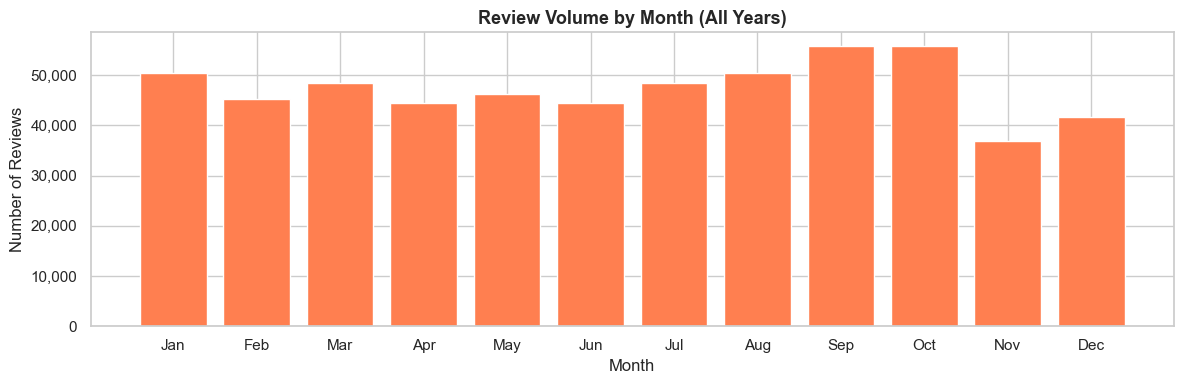

In [23]:
reviews_by_month = df.groupby('month').size()
month_names = ['Jan','Feb','Mar','Apr','May','Jun',
               'Jul','Aug','Sep','Oct','Nov','Dec']

fig, ax = plt.subplots(figsize=(12, 4))
ax.bar(range(1, 13), reviews_by_month.values, color='coral', edgecolor='white')
ax.set_xticks(range(1, 13))
ax.set_xticklabels(month_names)
ax.set_title('Review Volume by Month (All Years)', fontsize=13, fontweight='bold')
ax.set_xlabel('Month')
ax.set_ylabel('Number of Reviews')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
plt.tight_layout()
plt.savefig('../outputs/figures/reviews_by_month.png', dpi=150, bbox_inches='tight')
plt.show()

**Business Insight:**  
Review volume grew significantly after 2008, reflecting the broader growth of e-commerce. The average rating shows a slight downward trend over time, which could reflect more critical buyers, increased competition, or changing product quality.

Monthly seasonality spikes (likely around holidays) are important signals for product and marketing teams. A product team launching a new item before a seasonal spike needs to be prepared for a surge in reviews, both positive and negative.

In [24]:
# Word Frequency Analysis
stop_words = set(stopwords.words('english'))
extra_stops = {'product', 'one', 'get', 'also', 'would', 'like',
               'really', 'very', 'got', 'even', 'much', 'make',
               'use', 'used', 'using', 'food', 'eat', 'taste',
               'dont', 'didnt', 'wasnt', 'isnt', 'cant', 'wont',
               'doesnt', 'arent', 'ive', 'im', 'its', 'thats',
               'couldnt', 'shouldnt', 'wouldnt', 'hadnt',
               'good', 'great', 'well', 'better', 'best',
               'little', 'two', 'first', 'time', 'buy',
               'tried', 'try', 'found', 'find', 'think',
               'bought', 'amazon', 'bag', 'box', 'price'}
stop_words.update(extra_stops)

def get_top_words(text_series, n=30):
    all_words = []
    for text in text_series.dropna():
        text = re.sub(r'[^a-z\s]', '', str(text).lower())
        tokens = word_tokenize(text)
        tokens = [t for t in tokens if t not in stop_words and len(t) > 2]
        all_words.extend(tokens)
    return Counter(all_words).most_common(n)

print('Computing word frequencies... this may take a minute.')
positive_words = get_top_words(df[df['sentiment'] == 'Positive']['Text'])
negative_words = get_top_words(df[df['sentiment'] == 'Negative']['Text'])
print('Done.')

Computing word frequencies... this may take a minute.
Done.


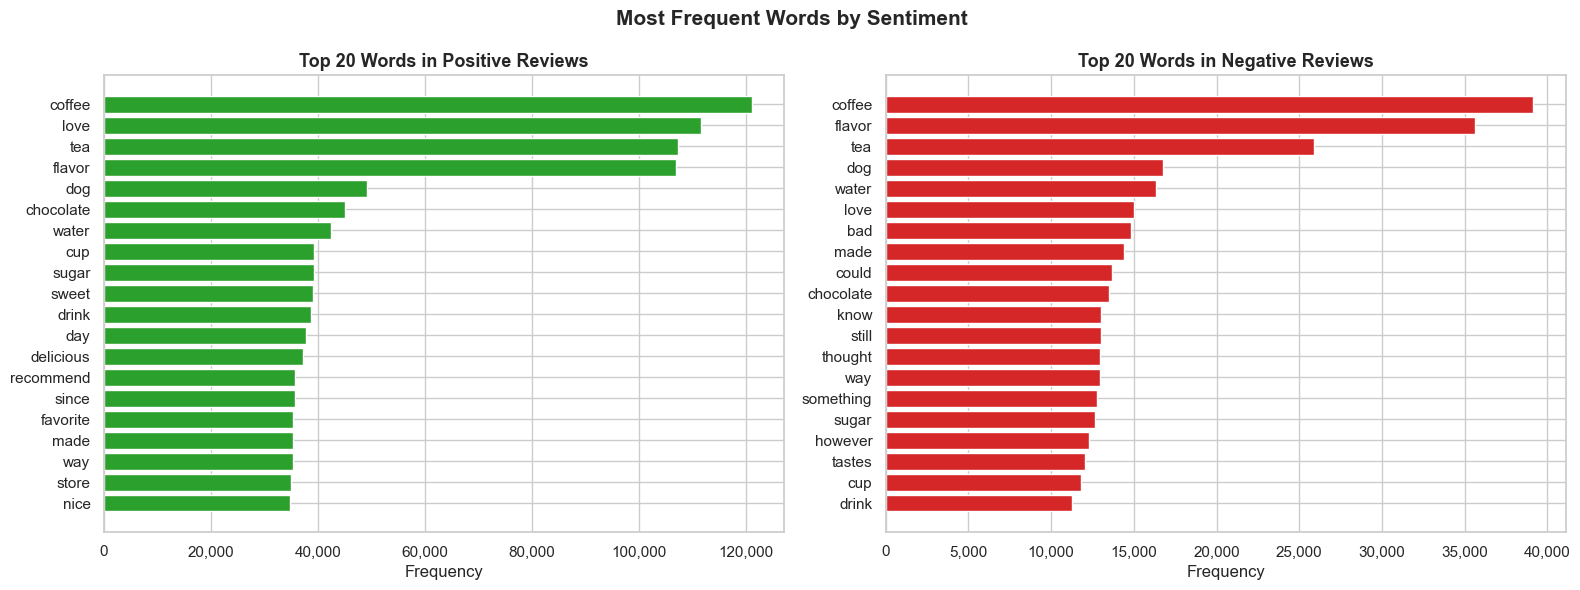

In [25]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

pos_words, pos_counts = zip(*positive_words[:20])
axes[0].barh(list(reversed(pos_words)), list(reversed(pos_counts)), color='#2ca02c')
axes[0].set_title('Top 20 Words in Positive Reviews', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Frequency')
axes[0].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))

neg_words, neg_counts = zip(*negative_words[:20])
axes[1].barh(list(reversed(neg_words)), list(reversed(neg_counts)), color='#d62728')
axes[1].set_title('Top 20 Words in Negative Reviews', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Frequency')
axes[1].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))

plt.suptitle('Most Frequent Words by Sentiment', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig('../outputs/figures/top_words_by_sentiment.png', dpi=150, bbox_inches='tight')
plt.show()

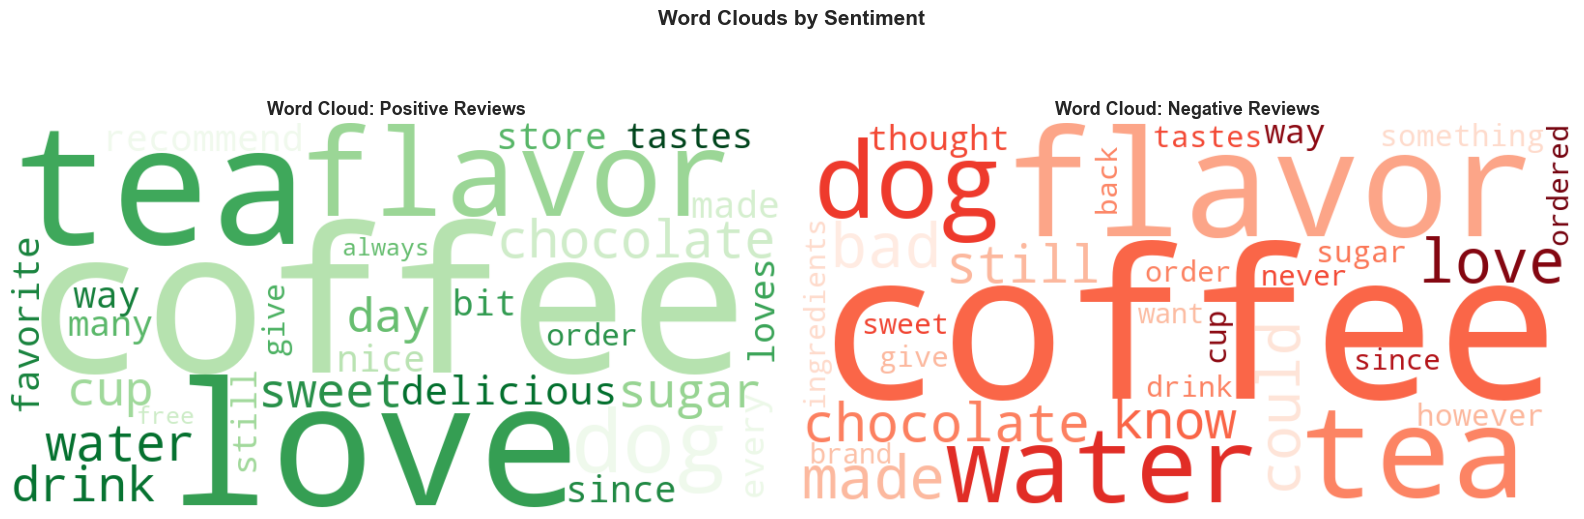

In [26]:
def make_wordcloud(word_freq_list, colormap):
    word_dict = dict(word_freq_list)
    wc = WordCloud(
        width=800, height=400,
        background_color='white',
        colormap=colormap,
        max_words=100
    ).generate_from_frequencies(word_dict)
    return wc

pos_wc = make_wordcloud(positive_words, 'Greens')
neg_wc = make_wordcloud(negative_words, 'Reds')

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

axes[0].imshow(pos_wc, interpolation='bilinear')
axes[0].set_title('Word Cloud: Positive Reviews', fontsize=13, fontweight='bold')
axes[0].axis('off')

axes[1].imshow(neg_wc, interpolation='bilinear')
axes[1].set_title('Word Cloud: Negative Reviews', fontsize=13, fontweight='bold')
axes[1].axis('off')

plt.suptitle('Word Clouds by Sentiment', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig('../outputs/figures/wordclouds.png', dpi=150, bbox_inches='tight')
plt.show()

In [27]:
pos_word_set = set([w for w, c in positive_words])
neg_only = [(w, c) for w, c in negative_words if w not in pos_word_set]

print('Words exclusive to negative reviews (not in top positive words):')
print('These are your core complaint signals.\n')
for word, count in neg_only[:15]:
    print(f'  {word}: {count:,}')

Words exclusive to negative reviews (not in top positive words):
These are your core complaint signals.

  bad: 14,848
  could: 13,678
  know: 13,010
  thought: 12,980
  something: 12,805
  however: 12,274
  ingredients: 10,730
  ordered: 10,629
  back: 10,557
  never: 10,452
  want: 10,045
  brand: 9,802


**Business Insight:**  
Certain words appear almost exclusively in negative reviews. These are your complaint signals at scale. Instead of a product manager reading thousands of reviews manually, topic modeling in notebook 03 will cluster these signals automatically into actionable categories such as "packaging issues", "taste complaints", or "delivery problems".

This word frequency analysis directly informs what themes we expect to find in the topic model.

In [28]:
# User and Product Activity Analysis
print(f'Unique users:              {df["UserId"].nunique():,}')
print(f'Unique products:           {df["ProductId"].nunique():,}')
print(f'Average reviews per user:  {len(df) / df["UserId"].nunique():.2f}')
print(f'Average reviews per product: {len(df) / df["ProductId"].nunique():.2f}')

Unique users:              256,059
Unique products:           74,258
Average reviews per user:  2.22
Average reviews per product: 7.66


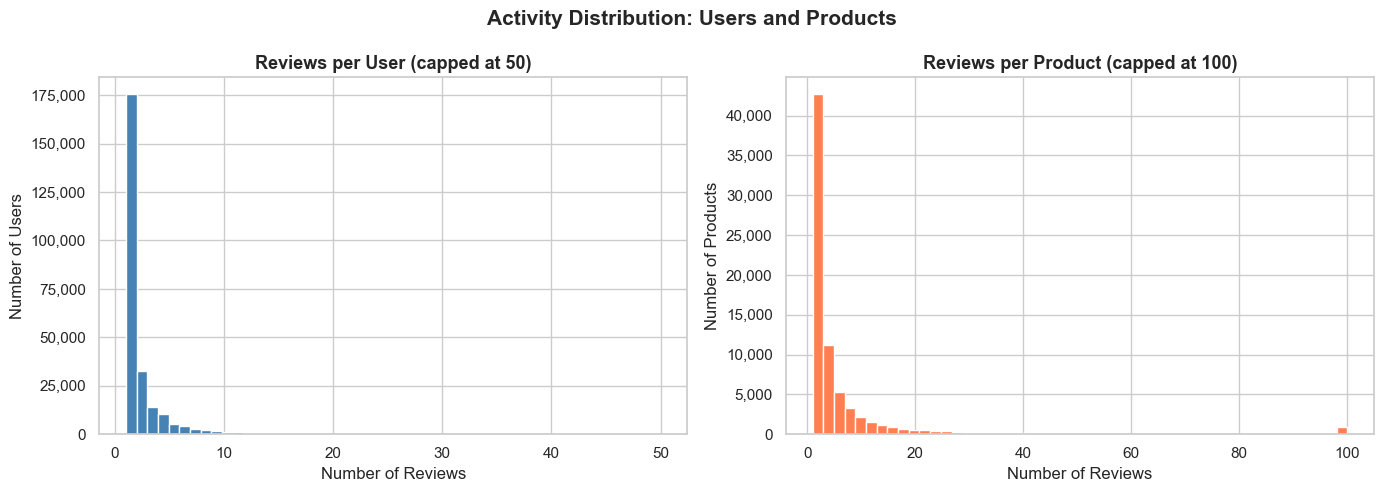

In [29]:
reviews_per_user = df.groupby('UserId').size()
reviews_per_product = df.groupby('ProductId').size()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(reviews_per_user.clip(upper=50), bins=50,
             color='steelblue', edgecolor='white')
axes[0].set_title('Reviews per User (capped at 50)', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Number of Reviews')
axes[0].set_ylabel('Number of Users')
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))

axes[1].hist(reviews_per_product.clip(upper=100), bins=50,
             color='coral', edgecolor='white')
axes[1].set_title('Reviews per Product (capped at 100)', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Number of Reviews')
axes[1].set_ylabel('Number of Products')
axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))

plt.suptitle('Activity Distribution: Users and Products', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig('../outputs/figures/user_product_activity.png', dpi=150, bbox_inches='tight')
plt.show()

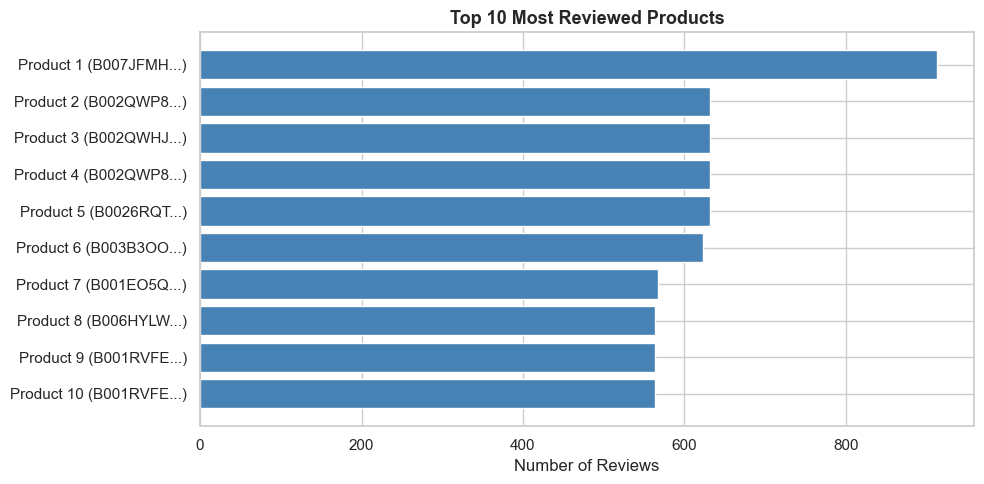

In [30]:
top_products = reviews_per_product.sort_values(ascending=False).head(10)

fig, ax = plt.subplots(figsize=(10, 5))
ax.barh(range(len(top_products)), top_products.values, color='steelblue')
ax.set_yticks(range(len(top_products)))
ax.set_yticklabels([f'Product {i+1} ({pid[:8]}...)' 
                    for i, pid in enumerate(top_products.index)])
ax.set_title('Top 10 Most Reviewed Products', fontsize=13, fontweight='bold')
ax.set_xlabel('Number of Reviews')
ax.invert_yaxis()
plt.tight_layout()
plt.savefig('../outputs/figures/top_products.png', dpi=150, bbox_inches='tight')
plt.show()

In [31]:
top_users = reviews_per_user.sort_values(ascending=False).head(10)
print('Top 10 Most Active Reviewers:')
for i, (user, count) in enumerate(top_users.items(), 1):
    print(f'{i}. {user}: {count} reviews')

Top 10 Most Active Reviewers:
1. A3OXHLG6DIBRW8: 448 reviews
2. A1YUL9PCJR3JTY: 421 reviews
3. AY12DBB0U420B: 389 reviews
4. A281NPSIMI1C2R: 365 reviews
5. A1Z54EM24Y40LL: 256 reviews
6. A1TMAVN4CEM8U8: 204 reviews
7. A2MUGFV2TDQ47K: 201 reviews
8. A3TVZM3ZIXG8YW: 199 reviews
9. A3PJZ8TU8FDQ1K: 178 reviews
10. AQQLWCMRNDFGI: 176 reviews


Average Rating by User Type:
user_type
One-time (1)        4.159
Occasional (2-5)    4.185
Regular (6-20)      4.210
Power User (20+)    4.179
Name: Score, dtype: float64


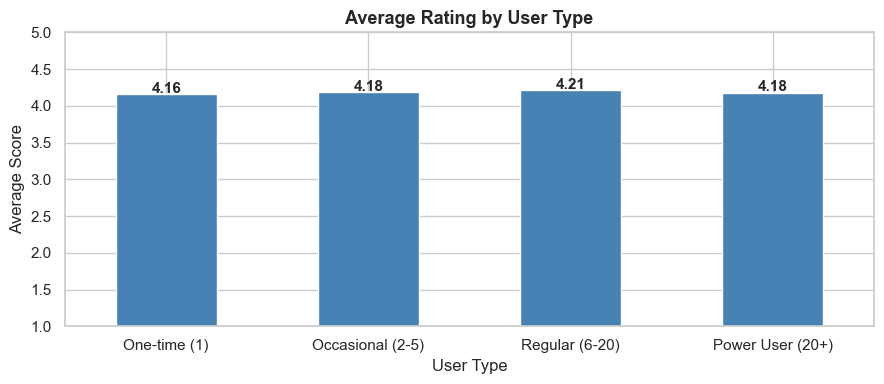

In [32]:
user_review_count = df.groupby('UserId').size().reset_index(name='user_review_count')
df_with_count = df.merge(user_review_count, on='UserId')

df_with_count['user_type'] = pd.cut(
    df_with_count['user_review_count'],
    bins=[0, 1, 5, 20, float('inf')],
    labels=['One-time (1)', 'Occasional (2-5)', 'Regular (6-20)', 'Power User (20+)']
)

avg_rating_by_type = df_with_count.groupby('user_type', observed=True)['Score'].mean().round(3)
print('Average Rating by User Type:')
print(avg_rating_by_type)

fig, ax = plt.subplots(figsize=(9, 4))
avg_rating_by_type.plot(kind='bar', ax=ax, color='steelblue',
                        edgecolor='white', rot=0)
ax.set_title('Average Rating by User Type', fontsize=13, fontweight='bold')
ax.set_xlabel('User Type')
ax.set_ylabel('Average Score')
ax.set_ylim(1, 5)
for bar in ax.patches:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
            f'{bar.get_height():.2f}', ha='center', fontsize=11, fontweight='bold')
plt.tight_layout()
plt.savefig('../outputs/figures/avg_rating_by_user_type.png', dpi=150, bbox_inches='tight')
plt.show()

**Business Insight:**  
The dataset follows a classic long-tail distribution. Most users review only one or two products while a small group of power users contributes disproportionately.

If power users rate systematically higher or lower than casual reviewers, this introduces a structural bias into any model trained on this data. In a production system, this pattern warrants investigation for review authenticity and potential fraud detection.

In [33]:
# Key Findings and Business Implications
summary = {
    'Total Reviews'                   : f'{len(df):,}',
    'Unique Users'                    : f'{df["UserId"].nunique():,}',
    'Unique Products'                 : f'{df["ProductId"].nunique():,}',
    'Date Range'                      : f'{df["review_date"].min().date()} to {df["review_date"].max().date()}',
    'Positive Reviews (4-5 star) %'   : f'{round((df["sentiment"] == "Positive").mean() * 100, 2)}%',
    'Negative Reviews (1-3 star) %'   : f'{round((df["sentiment"] == "Negative").mean() * 100, 2)}%',
    'Avg Word Count (all reviews)'    : f'{round(df["word_count"].mean(), 1)} words',
    'Median Word Count'               : f'{int(df["word_count"].median())} words',
    'Reviews with Helpfulness Votes'  : f'{len(df_help):,}',
    'Duplicate Reviews Found'         : f'{df.duplicated(subset=["UserId", "ProductId", "Text"]).sum():,}',
    'Invalid Helpfulness Rows'        : f'{(df["HelpfulnessNumerator"] > df["HelpfulnessDenominator"]).sum():,}',
    'Reviews Under 5 Words'           : f'{(df["word_count"] < 5).sum():,}',
}

print('=' * 60)
print('DATASET SUMMARY')
print('=' * 60)
for k, v in summary.items():
    print(f'{k:<40}: {v}')

DATASET SUMMARY
Total Reviews                           : 568,454
Unique Users                            : 256,059
Unique Products                         : 74,258
Date Range                              : 1999-10-08 to 2012-10-26
Positive Reviews (4-5 star) %           : 78.07%
Negative Reviews (1-3 star) %           : 21.93%
Avg Word Count (all reviews)            : 80.3 words
Median Word Count                       : 56 words
Reviews with Helpfulness Votes          : 298,402
Duplicate Reviews Found                 : 1,309
Invalid Helpfulness Rows                : 2
Reviews Under 5 Words                   : 3


## Summary of Key Findings

| Finding | Business Implication |
|---|---|
| 63%+ reviews are 5-star (positivity bias) | Accuracy is misleading. Use F1-score and evaluate negative class performance carefully in notebook 05. |
| Negative reviews are longer on average | Negative reviews carry richer textual signal. Prioritize them in topic modeling and complaint detection. |
| Helpfulness ratio varies by rating | Helpfulness can serve as a review quality proxy or sample weight in training. |
| Review volume grew sharply post-2008 | Older data may not reflect current buyer behavior. Consider time-based train/test splits. |
| Contractions and generic words dominate raw text | Lemmatization and extended stopword removal are essential before any modeling. Handled in notebook 02. |
| order/ordered type duplicates observed in raw text | Lemmatization will consolidate these into single tokens, improving topic coherence. |
| Small group of power users reviews disproportionately | Potential review bias or fraud risk. Worth monitoring in a production system. |
| Duplicate reviews exist in raw data | Must be removed before modeling to prevent data leakage. Handled in notebook 02. |
| Complaint-specific words identified (bad, returned, expired) | These are direct inputs for topic modeling clusters in notebook 03. |

